In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values
train_images = train_images / 255.0
test_images = test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


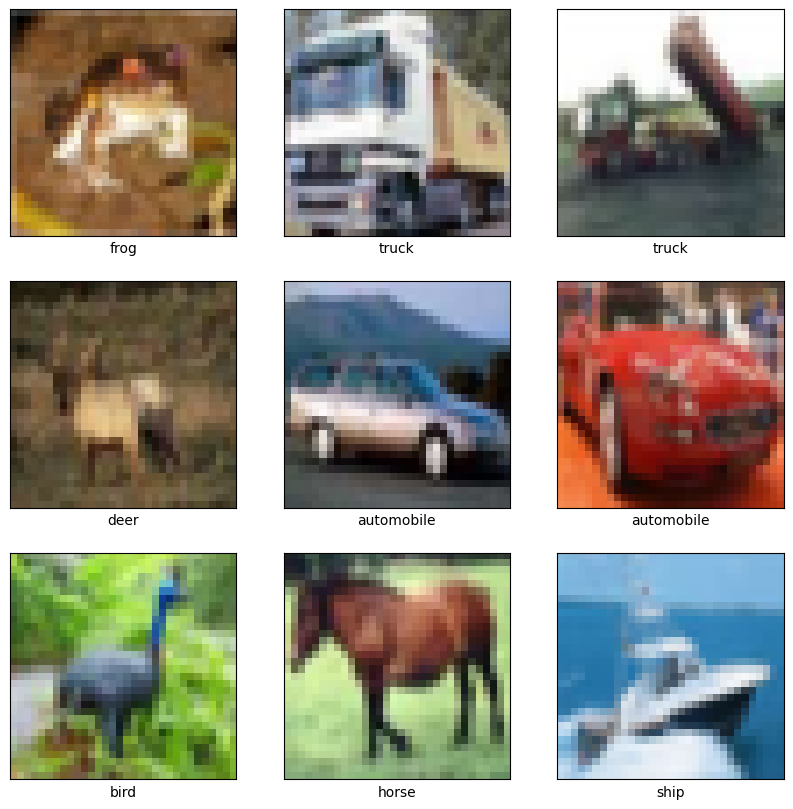

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
    plt.xticks([])
    plt.yticks([])

plt.show()

In [ ]:
model = models.Sequential()

# Convolution Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu',
                        input_shape=(32,32,3)))

# Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

# Convolution Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(64, activation='relu'))

# Output Layer
model.add(layers.Dense(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_images,
                    train_labels,
                    epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 41ms/step - accuracy: 0.4607 - loss: 1.4848 - val_accuracy: 0.5704 - val_loss: 1.2145
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 39ms/step - accuracy: 0.6032 - loss: 1.1239 - val_accuracy: 0.6299 - val_loss: 1.0643
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 38ms/step - accuracy: 0.6510 - loss: 0.9893 - val_accuracy: 0.6533 - val_loss: 0.9986
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.6823 - loss: 0.9091 - val_accuracy: 0.6674 - val_loss: 0.9683
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.7085 - loss: 0.8402 - val_accuracy: 0.6800 - val_loss: 0.9390
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.7264 - loss: 0.7827 - val_accuracy: 0.7002 - val_loss: 0.8853
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.7431 - loss: 0.7345 - val_accuracy: 0.6749 - val_loss: 0.9470
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.7585 -

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6947 - loss: 0.9491
Test Accuracy: 0.6947000026702881


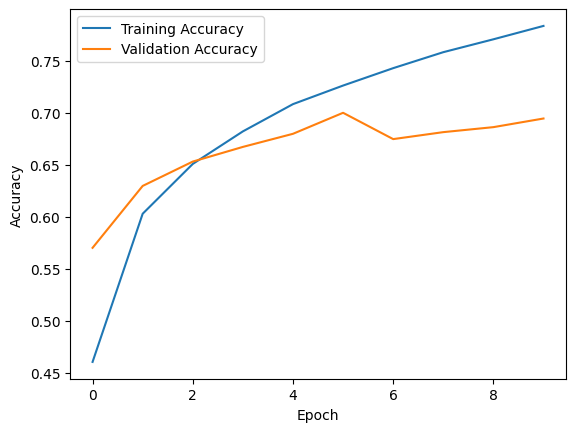

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
model.save("cnn_image_classifier.h5")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
